In [ ]:
!pip install evaluate jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 44.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q "/content/drive/MyDrive/census/dataset.zip" -d /content/new

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
"""
trocr_finetune.py — Оптимізований Fine-tuning TrOCR із розрахунком CER.

Перед запуском у Colab встановіть залежності:
  !pip install transformers datasets pillow torch torchvision evaluate jiwer -q

Запуск тренування (T4 GPU):
  !python trocr_finetune.py --dataset /content/dataset --output /content/trocr_revizki --batch-size 4 --accum-steps 4 --epochs 15
"""

import argparse
import csv
import os
import time
import json
from pathlib import Path

import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    get_linear_schedule_with_warmup,
)
import evaluate

# ── Автодетекція пристрою ────────────────────────────────────────────────────

def get_device():
    if torch.cuda.is_available():
        name = torch.cuda.get_device_name(0)
        vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"✓ Виявлено GPU: {name} ({vram:.1f}GB)")
        return torch.device("cuda")
    print("⚠ Режим CPU (вкрай повільно!)")
    return torch.device("cpu")


# ── Датасет ──────────────────────────────────────────────────────────────────

class RevizkiDataset(Dataset):
    """
    Завантажує пари (зображення рядка, текст) з labels.csv.
    Готує токени БЕЗ статичного падінгу для економії пам'яті.
    """
    def __init__(self, csv_path: str, images_dir: str, processor, max_length: int = 128):
        self.processor = processor
        self.max_length = max_length
        self.samples = []

        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"Не знайдено файл розмітки: {csv_path}")

        with open(csv_path, encoding="utf-8") as f:
            for row in csv.DictReader(f):
                # Підтримка відносних шляхів або просто імен файлів
                img_name = Path(row["file"]).name
                img_path = Path(images_dir) / img_name

                if img_path.exists() and row["text"].strip():
                    self.samples.append({
                        "image": str(img_path),
                        "text": row["text"].strip(),
                    })

        print(f"✓ Успішно завантажено {len(self.samples)} валідних зразків.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Завантаження зображення
        image = Image.open(sample["image"]).convert("RGB")
        pixel_values = self.processor(
            images=image, return_tensors="pt"
        ).pixel_values.squeeze(0)

        # Токенізація тексту без жорсткого padding
        labels = self.processor.tokenizer(
            sample["text"],
            max_length=self.max_length,
            padding=False,  # Падінг робиться динамічно у collate_fn
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)

        return {"pixel_values": pixel_values, "labels": labels}


# ── Динамічний Collate Function ──────────────────────────────────────────────

def trocr_collate_fn(batch):
    """
    Динамічно вирівнює довжину текстів (labels) під найдовший рядок у поточному батчі.
    Замінює стандартні PAD токени на -100 для ігнорування в loss.
    """
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels_list = [item["labels"] for item in batch]

    # Робимо падінг лише до максимальної довжини в цьому конкретному батчі
    labels = torch.nn.utils.rnn.pad_sequence(
        labels_list,
        batch_first=True,
        padding_value=-100  # PyTorch CrossEntropyLoss ігнорує -100 за замовчуванням
    )

    return {"pixel_values": pixel_values, "labels": labels}


# ── Тренування та Валідація ──────────────────────────────────────────────────

def train(args):
    device = get_device()

    # Завантаження метрики CER
    cer_metric = evaluate.load("cer")

    # Використовуємо кириличну ком'юніті-модель як базу
    model_name = "kazars24/trocr-base-handwritten-ru"
    if args.model_name:
        model_name = args.model_name

    print(f"\n[1/4] Завантаження базової моделі: {model_name}...")
    processor = TrOCRProcessor.from_pretrained(model_name)
    model = VisionEncoderDecoderModel.from_pretrained(model_name)

    # ── Розширення словника токенізатора під історичні літери ────────────────
    historical_tokens = ["ѣ", "Ѣ", "і", "І", "ъ", "Ъ", "ѳ", "Ѳ", "ѕ", "Ѕ", "ы"]
    added_count = processor.tokenizer.add_tokens(historical_tokens)

    if added_count > 0:
        print(f"  -> Додано {added_count} нових історичних токенів до словника.")
        # Розширюємо лінійний шар декодера моделі
        model.decoder.resize_token_embeddings(len(processor.tokenizer))
    # ─────────────────────────────────────────────────────────────────────────

    model = model.to(device)

    # Конфігурація токенів генерації текстів
    model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
    model.config.pad_token_id = processor.tokenizer.pad_token_id
    model.config.eos_token_id = processor.tokenizer.sep_token_id
    model.generation_config.max_length = 128
    model.generation_config.num_beams = 4

    print("\n[2/4] Підготовка датасету...")
    csv_path = Path(args.dataset) / "labels.csv"
    images_dir = Path(args.dataset) / "images"

    full_dataset = RevizkiDataset(str(csv_path), str(images_dir), processor)

    # Валідаційний спліт (90% навчання / 10% валідація)
    val_size = max(1, int(len(full_dataset) * 0.1))
    train_size = len(full_dataset) - val_size
    train_ds, val_ds = random_split(
        full_dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )
    print(f"  -> Навчальна вибірка: {train_size} рядків")
    print(f"  -> Валідаційна вибірка: {val_size} рядків")

    # Створення DataLoader з кастомним collate_fn
    train_loader = DataLoader(
        train_ds, batch_size=args.batch_size, shuffle=True,
        num_workers=2, collate_fn=trocr_collate_fn
    )
    val_loader = DataLoader(
        val_ds, batch_size=args.batch_size, shuffle=False,
        num_workers=2, collate_fn=trocr_collate_fn
    )

    # Оптимізатор та шедулер
    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=0.01)

    effective_steps = len(train_loader) // args.accum_steps
    total_steps = max(1, effective_steps * args.epochs)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, total_steps // 10),
        num_training_steps=total_steps,
    )

    output_dir = Path(args.output)
    output_dir.mkdir(parents=True, exist_ok=True)

    best_cer = float("inf")
    history = []

    print(f"\n[3/4] Старт навчання: {args.epochs} епох | Батч: {args.batch_size} (Акумуляція x{args.accum_steps})")
    print("=" * 70)

    for epoch in range(1, args.epochs + 1):
        # ── Крок Навчання ──
        model.train()
        train_loss = 0.0
        t0 = time.time()

        optimizer.zero_grad()

        for batch_idx, batch in enumerate(train_loader):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values, labels=labels)

            # Накопичення градієнтів
            loss = outputs.loss / args.accum_steps
            loss.backward()

            train_loss += outputs.loss.item()

            # Крок оптимізатора раз на N батчів
            if (batch_idx + 1) % args.accum_steps == 0 or (batch_idx + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            if (batch_idx + 1) % (args.accum_steps * 5) == 0:
                avg_current_loss = train_loss / (batch_idx + 1)
                print(f"  Епоха {epoch} [{batch_idx+1}/{len(train_loader)}] | Поточний Loss: {avg_current_loss:.4f}")

        avg_train_loss = train_loss / len(train_loader)

        # ── Крок Валідації та розрахунку CER ──
        model.eval()
        val_loss = 0.0
        val_predictions = []
        val_references = []

        with torch.no_grad():
            for batch in val_loader:
                pixel_values = batch["pixel_values"].to(device)
                labels = batch["labels"].to(device)

                # Обчислюємо валідаційний loss
                outputs = model(pixel_values=pixel_values, labels=labels)
                val_loss += outputs.loss.item()

                # Ауторегресивна генерація тексту для метрики CER
                generated_ids = model.generate(pixel_values, max_new_tokens=64, num_beams=4)
                predictions = processor.batch_decode(generated_ids, skip_special_tokens=True)

                # Декодуємо таргети (замінюємо маскування -100 назад на pad токен)
                cleaned_labels = labels.clone()
                cleaned_labels[cleaned_labels == -100] = processor.tokenizer.pad_token_id
                references = processor.batch_decode(cleaned_labels, skip_special_tokens=True)

                val_predictions.extend(predictions)
                val_references.extend(references)

        avg_val_loss = val_loss / len(val_loader)

        # Захист метрики від порожніх рядків у референсах
        valid_preds, valid_refs = [], []
        for p, r in zip(val_predictions, val_references):
            if r.strip():
                valid_preds.append(p)
                valid_refs.append(r)

        # Розрахунок точного CER
        if valid_refs:
            epoch_cer = cer_metric.compute(predictions=valid_preds, references=valid_refs)
        else:
            epoch_cer = 1.0

        elapsed = time.time() - t0

        # Зберігаємо історію метрик
        history.append({
            "epoch": epoch,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "cer": epoch_cer
        })

        print(f"\n>> Епоха {epoch}/{args.epochs} завершена за {elapsed:.0f}с")
        print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"   === Метрика MS1: [ VALIDATION CER: {epoch_cer:.4f} ] ===")
        print(f"   Приклади розпізнавання (Перші 3 рядки):")
        for i in range(min(3, len(valid_preds))):
            print(f"     Оригінал: '{valid_refs[i]}'")
            print(f"     Модель:   '{valid_preds[i]}'")
        print("-" * 70)

        # Зберігаємо найкращу модель за НАЙМЕНШИМ значенням CER
        if epoch_cer < best_cer:
            best_cer = epoch_cer
            best_dir = output_dir / "best"
            model.save_pretrained(best_dir)
            processor.save_pretrained(best_dir)
            print(f"  ✓ Нова найкраща модель збережена: {best_dir} (CER={best_cer:.4f})")

    # Фінальне збереження чекпоінту
    final_dir = output_dir / "final"
    model.save_pretrained(final_dir)
    processor.save_pretrained(final_dir)

    with open(output_dir / "history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)

    print(f"\n[4/4] Навчання успішно завершено! Кращий Baseline CER: {best_cer:.4f}")


# ── Швидкий Інференс (Тест одного файлу) ─────────────────────────────────────

def test_single_image(model_dir: str, image_path: str):
    """Допоміжна функція для тестування збереженої моделі на одному кропі рядка."""
    device = get_device()
    print(f"Завантаження моделі з {model_dir}...")

    processor = TrOCRProcessor.from_pretrained(model_dir)
    model = VisionEncoderDecoderModel.from_pretrained(model_dir).to(device)
    model.eval()

    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():
        generated = model.generate(pixel_values, max_new_tokens=128, num_beams=4)

    text = processor.decode(generated[0], skip_special_tokens=True)
    print(f"\n[Результат OCR інференсу]: {text}")
    return text


In [ ]:
import argparse

# Створюємо оновлений об'єкт з аргументами
args = argparse.Namespace(
    dataset="/content/new/dataset",
    output="/content/drive/MyDrive/trocr_revizki",
    model_name=None,        # 1. Поміняли 'model' на 'model_name'
    epochs=15,
    batch_size=4,
    accum_steps=4,         # 2. ДОДАЛИ кроки акумуляції градієнта (критично для T4)
    lr=4e-5,               # Трохи знизили для стабільності з акумуляцією
    test_img=None,         # 3. Поміняли 'test' на 'test_img'
    test_model=None
)

# Запускаємо навчання
train(args)

✓ Виявлено GPU: Tesla T4 (14.6GB)

[1/4] Завантаження базової моделі: kazars24/trocr-base-handwritten-ru...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

  -> Додано 11 нових історичних токенів до словника.

[2/4] Підготовка датасету...
✓ Успішно завантажено 707 валідних зразків.
  -> Навчальна вибірка: 637 рядків
  -> Валідаційна вибірка: 70 рядків

[3/4] Старт навчання: 15 епох | Батч: 4 (Акумуляція x4)
  Епоха 1 [20/160] | Поточний Loss: 4.9696
  Епоха 1 [40/160] | Поточний Loss: 4.8563
  Епоха 1 [60/160] | Поточний Loss: 4.5904
  Епоха 1 [80/160] | Поточний Loss: 4.3491
  Епоха 1 [100/160] | Поточний Loss: 4.1711
  Епоха 1 [120/160] | Поточний Loss: 4.0123
  Епоха 1 [140/160] | Поточний Loss: 3.8822
  Епоха 1 [160/160] | Поточний Loss: 3.7489


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 1/15 завершена за 248с
   Train Loss: 3.7489 | Val Loss: 2.5609
   === Метрика MS1: [ VALIDATION CER: 0.6514 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'Слего предою ремипо'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'депоренна поманний по'
     Оригінал: 'ревизіи'
     Модель:   'репревий'
----------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Нова найкраща модель збережена: /content/drive/MyDrive/trocr_revizki/best (CER=0.6514)
  Епоха 2 [20/160] | Поточний Loss: 2.4079
  Епоха 2 [40/160] | Поточний Loss: 2.4785
  Епоха 2 [60/160] | Поточний Loss: 2.3920
  Епоха 2 [80/160] | Поточний Loss: 2.3176
  Епоха 2 [100/160] | Поточний Loss: 2.2692
  Епоха 2 [120/160] | Поточний Loss: 2.2094
  Епоха 2 [140/160] | Поточний Loss: 2.1595
  Епоха 2 [160/160] | Поточний Loss: 2.1064


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 2/15 завершена за 240с
   Train Loss: 2.1064 | Val Loss: 1.6560
   === Метрика MS1: [ VALIDATION CER: 0.5126 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'слюю предочь ревиза'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'жестарний послаговаю'
     Оригінал: 'ревизіи'
     Модель:   'ревий'
----------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Нова найкраща модель збережена: /content/drive/MyDrive/trocr_revizki/best (CER=0.5126)
  Епоха 3 [20/160] | Поточний Loss: 1.3182
  Епоха 3 [40/160] | Поточний Loss: 1.3810
  Епоха 3 [60/160] | Поточний Loss: 1.3725
  Епоха 3 [80/160] | Поточний Loss: 1.3411
  Епоха 3 [100/160] | Поточний Loss: 1.3060
  Епоха 3 [120/160] | Поточний Loss: 1.2762
  Епоха 3 [140/160] | Поточний Loss: 1.2629
  Епоха 3 [160/160] | Поточний Loss: 1.2364


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 3/15 завершена за 258с
   Train Loss: 1.2364 | Val Loss: 1.0525
   === Метрика MS1: [ VALIDATION CER: 0.4058 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'Следнюю предъ си ревизъю'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'денкревий плапасананнова у'
     Оригінал: 'ревизіи'
     Модель:   'ревизи'
----------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Нова найкраща модель збережена: /content/drive/MyDrive/trocr_revizki/best (CER=0.4058)
  Епоха 4 [20/160] | Поточний Loss: 0.7904
  Епоха 4 [40/160] | Поточний Loss: 0.7997
  Епоха 4 [60/160] | Поточний Loss: 0.7772
  Епоха 4 [80/160] | Поточний Loss: 0.7772
  Епоха 4 [100/160] | Поточний Loss: 0.7534
  Епоха 4 [120/160] | Поточний Loss: 0.7310
  Епоха 4 [140/160] | Поточний Loss: 0.7294
  Епоха 4 [160/160] | Поточний Loss: 0.7195


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 4/15 завершена за 255с
   Train Loss: 0.7195 | Val Loss: 0.8738
   === Метрика MS1: [ VALIDATION CER: 0.3373 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'слъднюю предъ симъ ревизъю'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'жентревий Плазаннъю ре въ'
     Оригінал: 'ревизіи'
     Модель:   'ревизъи'
----------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Нова найкраща модель збережена: /content/drive/MyDrive/trocr_revizki/best (CER=0.3373)
  Епоха 5 [20/160] | Поточний Loss: 0.5280
  Епоха 5 [40/160] | Поточний Loss: 0.5108
  Епоха 5 [60/160] | Поточний Loss: 0.5525
  Епоха 5 [80/160] | Поточний Loss: 0.5301
  Епоха 5 [100/160] | Поточний Loss: 0.5202
  Епоха 5 [120/160] | Поточний Loss: 0.5215
  Епоха 5 [140/160] | Поточний Loss: 0.5297
  Епоха 5 [160/160] | Поточний Loss: 0.5238


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 5/15 завершена за 264с
   Train Loss: 0.5238 | Val Loss: 0.8449
   === Метрика MS1: [ VALIDATION CER: 0.3555 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'слъднюю предъ симъ ревизъю'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'женарний Плаховановъ умре въ'
     Оригінал: 'ревизіи'
     Модель:   'ревизъи'
----------------------------------------------------------------------
  Епоха 6 [20/160] | Поточний Loss: 0.3288
  Епоха 6 [40/160] | Поточний Loss: 0.3748
  Епоха 6 [60/160] | Поточний Loss: 0.3945
  Епоха 6 [80/160] | Поточний Loss: 0.3774
  Епоха 6 [100/160] | Поточний Loss: 0.3753
  Епоха 6 [120/160] | Поточний Loss: 0.3788
  Епоха 6 [140/160] | Поточний Loss: 0.3902
  Епоха 6 [160/160] | Поточний Loss: 0.3879


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 6/15 завершена за 263с
   Train Loss: 0.3879 | Val Loss: 0.8406
   === Метрика MS1: [ VALIDATION CER: 0.3524 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'слъднюю предъ симъ ревизъю'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'жентронъй поствочьяновъ  783'
     Оригінал: 'ревизіи'
     Модель:   'рови'
----------------------------------------------------------------------
  Епоха 7 [20/160] | Поточний Loss: 0.2771
  Епоха 7 [40/160] | Поточний Loss: 0.3240
  Епоха 7 [60/160] | Поточний Loss: 0.3175
  Епоха 7 [80/160] | Поточний Loss: 0.2943
  Епоха 7 [100/160] | Поточний Loss: 0.2831
  Епоха 7 [120/160] | Поточний Loss: 0.2827
  Епоха 7 [140/160] | Поточний Loss: 0.2941
  Епоха 7 [160/160] | Поточний Loss: 0.2922


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 7/15 завершена за 261с
   Train Loss: 0.2922 | Val Loss: 0.7997
   === Метрика MS1: [ VALIDATION CER: 0.2921 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'слѣднюю предъ симъ ревизъю'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'жентревъй Плазановъ сумъ умреннию'
     Оригінал: 'ревизіи'
     Модель:   'ревизіи'
----------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Нова найкраща модель збережена: /content/drive/MyDrive/trocr_revizki/best (CER=0.2921)
  Епоха 8 [20/160] | Поточний Loss: 0.1922
  Епоха 8 [40/160] | Поточний Loss: 0.1859
  Епоха 8 [60/160] | Поточний Loss: 0.2026
  Епоха 8 [80/160] | Поточний Loss: 0.2071
  Епоха 8 [100/160] | Поточний Loss: 0.2080
  Епоха 8 [120/160] | Поточний Loss: 0.2105
  Епоха 8 [140/160] | Поточний Loss: 0.2107
  Епоха 8 [160/160] | Поточний Loss: 0.2075


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 8/15 завершена за 248с
   Train Loss: 0.2075 | Val Loss: 0.8093
   === Метрика MS1: [ VALIDATION CER: 0.2808 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'слѣднюю предъ симъ ревизію'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'У наревъй Плагасановъ умре'
     Оригінал: 'ревизіи'
     Модель:   'ревизіи'
----------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Нова найкраща модель збережена: /content/drive/MyDrive/trocr_revizki/best (CER=0.2808)
  Епоха 9 [20/160] | Поточний Loss: 0.1530
  Епоха 9 [40/160] | Поточний Loss: 0.1615
  Епоха 9 [60/160] | Поточний Loss: 0.1653
  Епоха 9 [80/160] | Поточний Loss: 0.1637
  Епоха 9 [100/160] | Поточний Loss: 0.1584
  Епоха 9 [120/160] | Поточний Loss: 0.1594
  Епоха 9 [140/160] | Поточний Loss: 0.1577
  Епоха 9 [160/160] | Поточний Loss: 0.1584


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 9/15 завершена за 251с
   Train Loss: 0.1584 | Val Loss: 0.7803
   === Метрика MS1: [ VALIDATION CER: 0.2795 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'слѣднюю предъ симъ ревизію'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'зятронъй Плихованковъ умревъ'
     Оригінал: 'ревизіи'
     Модель:   'ревизіи'
----------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Нова найкраща модель збережена: /content/drive/MyDrive/trocr_revizki/best (CER=0.2795)
  Епоха 10 [20/160] | Поточний Loss: 0.0828
  Епоха 10 [40/160] | Поточний Loss: 0.1070
  Епоха 10 [60/160] | Поточний Loss: 0.1149
  Епоха 10 [80/160] | Поточний Loss: 0.1136
  Епоха 10 [100/160] | Поточний Loss: 0.1215
  Епоха 10 [120/160] | Поточний Loss: 0.1202
  Епоха 10 [140/160] | Поточний Loss: 0.1157
  Епоха 10 [160/160] | Поточний Loss: 0.1154


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 10/15 завершена за 256с
   Train Loss: 0.1154 | Val Loss: 0.8172
   === Метрика MS1: [ VALIDATION CER: 0.2789 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'слѣднюю предъ симъ ревизію'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'женаровъ сы Плаковазъю'
     Оригінал: 'ревизіи'
     Модель:   'ревизіи'
----------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Нова найкраща модель збережена: /content/drive/MyDrive/trocr_revizki/best (CER=0.2789)
  Епоха 11 [20/160] | Поточний Loss: 0.0824
  Епоха 11 [40/160] | Поточний Loss: 0.0855
  Епоха 11 [60/160] | Поточний Loss: 0.0854
  Епоха 11 [80/160] | Поточний Loss: 0.0814
  Епоха 11 [100/160] | Поточний Loss: 0.0803
  Епоха 11 [120/160] | Поточний Loss: 0.0797
  Епоха 11 [140/160] | Поточний Loss: 0.0797
  Епоха 11 [160/160] | Поточний Loss: 0.0816


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 11/15 завершена за 257с
   Train Loss: 0.0816 | Val Loss: 0.7813
   === Метрика MS1: [ VALIDATION CER: 0.2651 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'слѣднюю предъ симъ ревизію'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'жеревъй Плихасковъ сыхъ'
     Оригінал: 'ревизіи'
     Модель:   'ревизіи'
----------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Нова найкраща модель збережена: /content/drive/MyDrive/trocr_revizki/best (CER=0.2651)
  Епоха 12 [20/160] | Поточний Loss: 0.0616
  Епоха 12 [40/160] | Поточний Loss: 0.0638
  Епоха 12 [60/160] | Поточний Loss: 0.0658
  Епоха 12 [80/160] | Поточний Loss: 0.0659
  Епоха 12 [100/160] | Поточний Loss: 0.0647
  Епоха 12 [120/160] | Поточний Loss: 0.0629
  Епоха 12 [140/160] | Поточний Loss: 0.0611
  Епоха 12 [160/160] | Поточний Loss: 0.0613


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 12/15 завершена за 255с
   Train Loss: 0.0613 | Val Loss: 0.7800
   === Метрика MS1: [ VALIDATION CER: 0.2632 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'слѣднюю предъ симъ ревизію'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'жентревъй показенные послѣ'
     Оригінал: 'ревизіи'
     Модель:   'ревизіи'
----------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Нова найкраща модель збережена: /content/drive/MyDrive/trocr_revizki/best (CER=0.2632)
  Епоха 13 [20/160] | Поточний Loss: 0.0427
  Епоха 13 [40/160] | Поточний Loss: 0.0562
  Епоха 13 [60/160] | Поточний Loss: 0.0535
  Епоха 13 [80/160] | Поточний Loss: 0.0507
  Епоха 13 [100/160] | Поточний Loss: 0.0501
  Епоха 13 [120/160] | Поточний Loss: 0.0530
  Епоха 13 [140/160] | Поточний Loss: 0.0494
  Епоха 13 [160/160] | Поточний Loss: 0.0504


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 13/15 завершена за 251с
   Train Loss: 0.0504 | Val Loss: 0.8003
   === Метрика MS1: [ VALIDATION CER: 0.2557 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'слѣднюю предъ симъ ревизію'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'жентревъй Плапихановъ умре'
     Оригінал: 'ревизіи'
     Модель:   'ревизіи'
----------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Нова найкраща модель збережена: /content/drive/MyDrive/trocr_revizki/best (CER=0.2557)
  Епоха 14 [20/160] | Поточний Loss: 0.0262
  Епоха 14 [40/160] | Поточний Loss: 0.0338
  Епоха 14 [60/160] | Поточний Loss: 0.0350
  Епоха 14 [80/160] | Поточний Loss: 0.0343
  Епоха 14 [100/160] | Поточний Loss: 0.0394
  Епоха 14 [120/160] | Поточний Loss: 0.0390
  Епоха 14 [140/160] | Поточний Loss: 0.0381
  Епоха 14 [160/160] | Поточний Loss: 0.0384


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 14/15 завершена за 257с
   Train Loss: 0.0384 | Val Loss: 0.7887
   === Метрика MS1: [ VALIDATION CER: 0.2550 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'слѣднюю предъ симъ ревизію'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'жентревъй Плазенные послудъ'
     Оригінал: 'ревизіи'
     Модель:   'ревизіи'
----------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Нова найкраща модель збережена: /content/drive/MyDrive/trocr_revizki/best (CER=0.2550)
  Епоха 15 [20/160] | Поточний Loss: 0.0217
  Епоха 15 [40/160] | Поточний Loss: 0.0271
  Епоха 15 [60/160] | Поточний Loss: 0.0275
  Епоха 15 [80/160] | Поточний Loss: 0.0249
  Епоха 15 [100/160] | Поточний Loss: 0.0285
  Епоха 15 [120/160] | Поточний Loss: 0.0284
  Епоха 15 [140/160] | Поточний Loss: 0.0295
  Епоха 15 [160/160] | Поточний Loss: 0.0299


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


>> Епоха 15/15 завершена за 258с
   Train Loss: 0.0299 | Val Loss: 0.7929
   === Метрика MS1: [ VALIDATION CER: 0.2500 ] ===
   Приклади розпізнавання (Перші 3 рядки):
     Оригінал: 'слѣднюю предъ симъ ревизію'
     Модель:   'слѣднюю предъ симъ ревизію'
     Оригінал: 'детъ  по ревизіи показанъ бу'
     Модель:   'женаревъй Плихасковъ умъ'
     Оригінал: 'ревизіи'
     Модель:   'ревизіи'
----------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Нова найкраща модель збережена: /content/drive/MyDrive/trocr_revizki/best (CER=0.2500)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[4/4] Навчання успішно завершено! Кращий Baseline CER: 0.2500


In [ ]:
model_dir = "/content/drive/MyDrive/trocr_revizki/best"
image_path = "/content/test_1.jpg"

# Виклик функції
test_single_image(model_dir, image_path)

✓ Виявлено GPU: Tesla T4 (14.6GB)
Завантаження моделі з /content/drive/MyDrive/trocr_revizki/best...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Результат OCR інференсу]: Стастанъ въ мейль вапость


'Стастанъ въ мейль вапость'

In [ ]:
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# 1. Визначаємо шлях до вашої моделі та девайс
MODEL_DIR = "/content/drive/MyDrive/trocr_revizki/best"  # Замініть на свій model_dir
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Завантаження моделі з {MODEL_DIR} на {device}...")

# 2. Завантажуємо процесор та модель ОДИН РАЗ
ocr_processor = TrOCRProcessor.from_pretrained(MODEL_DIR)
ocr_model = VisionEncoderDecoderModel.from_pretrained(MODEL_DIR).to(device)
ocr_model.eval()

# 3. Функція для миттєвого тестування (використовує вже глобально завантажену модель)
def run_fast_ocr(image_path: str):
    image = Image.open(image_path).convert("RGB")

    # Інференс без повторного завантаження ваги
    pixel_values = ocr_processor(images=image, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():
        generated = ocr_model.generate(pixel_values, max_new_tokens=128, num_beams=4)

    text = ocr_processor.decode(generated[0], skip_special_tokens=True)
    print(f"\n[Результат OCR інференсу]: {text}")
    return text

print("Модель успішно завантажена та готова до швидкої роботи!")


Завантаження моделі з /content/drive/MyDrive/trocr_revizki/best на cuda...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Модель успішно завантажена та готова до швидкої роботи!


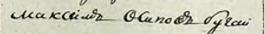

[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Результат OCR інференсу]: Мажескимъ  Осапорь бужали


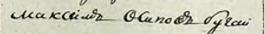

[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Результат OCR інференсу]: Мажескимъ  Осапорь бужали


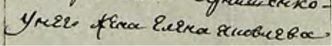

[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Результат OCR інференсу]: У него жена Еленова Яковля ва


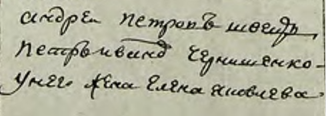

[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Результат OCR інференсу]: Сидорій Къ сызанъ въ 790 году 28  бѣжалалѣ в стажеланна вакапо каль ренаковъ ду


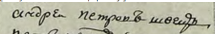

[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Результат OCR інференсу]: сѣнедорей Пестуда в умре въ 789 году


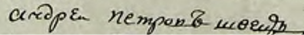

[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Результат OCR інференсу]: сяндоріе по туже въ    Ша валъ


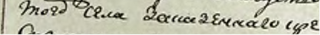

[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Результат OCR інференсу]: Того села Зожечана зеннаго кре


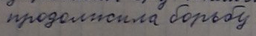

[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Результат OCR інференсу]: продолжесила борь86 году


In [ ]:
import IPython
import base64
from google.colab import output

html_code = """
<div id="paste-box" style="border: 2px dashed #28a745; padding: 25px; text-align: center; cursor: pointer; background-color: #f4fbf6; border-radius: 8px;">
  <span style="color: #28a745; font-weight: bold;">Клікніть сюди та натисніть Ctrl+V</span> для миттєвого OCR тесту
</div>
<script>
document.addEventListener('paste', async (e) => {
  const items = e.clipboardData.items;
  for (let i = 0; i < items.length; i++) {
    if (items[i].type.indexOf('image') !== -1) {
      const blob = items[i].getAsFile();
      const reader = new FileReader();
      reader.onload = (event) => {
        google.colab.kernel.invokeFunction('notebook.ProcessPastedImage', [event.target.result], {});
      };
      reader.readAsDataURL(blob);
    }
  }
});
</script>
"""

def process_pasted_image(base64_string):
    # Очищаємо екран від попередніх результатів, залишаючи плашку для вставки
    output.clear(output_tags='image-preview')

    # Декодуємо та зберігаємо файл
    header, encoded = base64_string.split(",", 1)
    data = base64.b64decode(encoded)
    filename = 'pasted_image.png'

    with open(filename, 'wb') as f:
        f.write(data)

    # Відображаємо картинку в Colab
    IPython.display.display(IPython.display.Image(filename))

    # Запускаємо «прогріту» модель ОСР
    run_fast_ocr(filename)

# Реєструємо функцію та виводимо поле вставки
output.register_callback('notebook.ProcessPastedImage', process_pasted_image)
IPython.display.display(IPython.display.HTML(html_code))
